# Case Study 2 — Sequence Models on Binance USDT Perpetuals

**Hypothesis:** A deep sequence model — LSTM or TCN — on a window of returns + funding-rate + open-interest features predicts next-day direction better than a coin flip on liquid USDT-margined perpetuals, and a daily-rebalanced top/bottom-quintile long/short portfolio survives the higher cost regime (`CRYPTO_PERP` ≈ 6 bps round-trip).

**The two models, side-by-side:**

- **LSTM** — the canonical "deep learning for time series" recipe in 90% of retail blog posts. The recognisable target.
- **TCN** (dilated causal 1D convolutions) — the modern alternative; faster, more deterministic, often as strong on benchmarks. The literature pick.

Same eval harness as case study 1 — purged + embargoed walk-forward CV, deflated Sharpe, bootstrap CI, per-regime breakdown — so the numbers are comparable.

Required env: none (Binance public REST). `data_cache/binance/` holds same-day caches.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
load_dotenv(ROOT / '.env', override=True)

from backtester.data.binance import fetch_klines, fetch_funding_rate
from backtester.features import (
    rolling_volatility, rsi, macd, momentum_rank, vol_rank,
    funding_features, open_interest_delta,
)
from backtester.eval.walkforward import walk_forward_splits
from backtester.eval.statistics import (
    annualised_sharpe, deflated_sharpe_ratio, bootstrap_ci,
)
from backtester.eval.costs import CRYPTO_PERP
from backtester.eval.regimes import trend_regimes, per_regime_metrics
from backtester.strategy import (
    long_short_quantile_weights, daily_returns_from_book, apply_book_costs,
)
from backtester.models import LSTMClassifier, TCNClassifier, stack_sequences

pd.options.display.float_format = '{:,.4f}'.format
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True})
RNG = np.random.default_rng(42)

# Top-10 USDT perps by long-run liquidity (rough proxy).
SYMBOLS = [
    'BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT',
    'DOGEUSDT', 'ADAUSDT', 'AVAXUSDT', 'LINKUSDT', 'MATICUSDT',
]
START = '2021-01-01'
END = '2024-12-31'
LOOKBACK = 30
LABEL_HORIZON = 1
TOP_BOTTOM_QUANTILE = 0.2
N_SPLITS = 5
EMBARGO = 5
EPOCHS = 6
HIDDEN = 32
BATCH_SIZE = 1024
MAX_BARS = 1500  # cap per symbol for speed; ~4 years of daily bars

## 1. Pull klines + funding from Binance

Public endpoints, paginated by 1000-bar limit. Cached on disk by `data_cache/binance/{symbol}_{params}_{date}.csv`.

In [2]:
def fetch_paginated_klines(symbol: str, *, start: str, end: str) -> pd.DataFrame:
    chunks = []
    cursor = pd.Timestamp(start, tz='UTC')
    end_ts = pd.Timestamp(end, tz='UTC')
    while cursor < end_ts and sum(c.shape[0] for c in chunks) < MAX_BARS:
        chunk = fetch_klines(symbol, interval='1d', market='futures',
                              start=cursor.isoformat(), end=end_ts.isoformat())
        if chunk.empty:
            break
        chunks.append(chunk)
        new_cursor = chunk.index.max() + pd.Timedelta(days=1)
        if new_cursor <= cursor:
            break
        cursor = new_cursor
        if chunk.shape[0] < 1000:
            break
    if not chunks:
        return pd.DataFrame()
    out = pd.concat(chunks).sort_index()
    return out[~out.index.duplicated(keep='first')]

klines = {}
fundings = {}
missing = []
for sym in SYMBOLS:
    try:
        k = fetch_paginated_klines(sym, start=START, end=END)
        if k.empty:
            raise RuntimeError('no klines')
        klines[sym] = k
        try:
            fundings[sym] = fetch_funding_rate(sym, start=START, end=END)['funding_rate']
        except Exception:
            fundings[sym] = pd.Series(dtype=float)
    except Exception as exc:  # noqa: BLE001
        missing.append((sym, str(exc)[:80]))

px = pd.DataFrame({s: k['close'] for s, k in klines.items()}).sort_index()
px.index = pd.DatetimeIndex(px.index).tz_localize(None)
print(f'Symbols loaded: {px.shape[1]} / {len(SYMBOLS)}')
print(f'Price panel: {px.shape[0]} rows × {px.shape[1]} cols, '
      f'{px.index.min().date()} → {px.index.max().date()}')
if missing:
    print('\nMissing:')
    for sym, msg in missing:
        print(f'  {sym}: {msg}')

Symbols loaded: 10 / 10
Price panel: 1461 rows × 10 cols, 2021-01-01 → 2024-12-31


## 2. Build the feature panel

Features per (date, ticker): 5/20-day momentum, 20-day vol, RSI(14), MACD line, cross-sectional momentum & vol ranks, funding-rate level + 1d/7d change. All leakage-free.

In [3]:
rets = px.pct_change(fill_method=None)
log_rets = np.log(px).diff()

tech_blocks = []
for sym in px.columns:
    s = px[sym]
    block = pd.DataFrame({
        'ret_1':     s.pct_change(1, fill_method=None),
        'mom_5':     s.pct_change(5, fill_method=None),
        'mom_20':    s.pct_change(20, fill_method=None),
        'vol_20':    rolling_volatility(log_rets[sym], window=20, annualise=365),
        'rsi_14':    rsi(s, period=14),
        'macd_line': macd(s)['macd_line'],
    })
    block['ticker'] = sym
    block.index.name = 'datetime'
    tech_blocks.append(block.reset_index())
tech_long = pd.concat(tech_blocks, ignore_index=True).set_index(['datetime', 'ticker']).sort_index()

mom_panel = momentum_rank(px, lookback=63, skip=10)
vol_panel = vol_rank(rets, window=30)
tech_long['mom_rank'] = mom_panel.stack().reindex(tech_long.index).values
tech_long['vol_rank'] = vol_panel.stack().reindex(tech_long.index).values

funding_blocks = []
for sym, fr in fundings.items():
    if fr.empty:
        continue
    feat = funding_features(fr, calendar=px.index)
    feat['ticker'] = sym
    feat.index.name = 'datetime'
    funding_blocks.append(feat.reset_index())
if funding_blocks:
    funding_long = (
        pd.concat(funding_blocks, ignore_index=True)
        .set_index(['datetime', 'ticker']).sort_index()
    )
    tech_long = tech_long.join(funding_long, how='left')
    print(f'Funding features merged for {len(funding_blocks)} symbols')
else:
    print('No funding data — skipping funding features')

panel = tech_long.dropna()
feature_cols = [c for c in panel.columns if c not in {'ticker'}]
print(f'Panel rows after dropna: {len(panel):,}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
panel.head()

Funding features merged for 10 symbols
Panel rows after dropna: 13,769
Feature columns (11): ['ret_1', 'mom_5', 'mom_20', 'vol_20', 'rsi_14', 'macd_line', 'mom_rank', 'vol_rank', 'funding_level', 'funding_chg_1d', 'funding_chg_7d']


ret_1   mom_5  mom_20  vol_20  rsi_14  macd_line  \
datetime   ticker                                                        
2021-03-15 ADAUSDT  -0.0209 -0.0894  0.0726  1.1351 48.3960     0.0427   
           AVAXUSDT  0.0052 -0.0221  0.0513  1.9078 50.5637     0.2752   
           BNBUSDT  -0.0333 -0.0858  0.1019  1.5838 55.0724    25.0995   
           BTCUSDT  -0.0574 -0.0054  0.1373  0.7735 58.0165 3,123.8159   
           DOGEUSDT -0.0187  0.0202  0.1971  1.5079 54.1059     0.0023   

                     mom_rank  vol_rank  funding_level  funding_chg_1d  \
datetime   ticker                                                        
2021-03-15 ADAUSDT     0.6000    0.5000         0.0017          0.0016   
           AVAXUSDT    0.7000    0.7000         0.0022          0.0010   
           BNBUSDT     0.5000    1.0000         0.0012          0.0009   
           BTCUSDT     0.1000    0.1000         0.0008          0.0002   
           DOGEUSDT    0.9000    0.6000         0.0020          0.0010   

                     funding_chg_7d  
datetime   ticker                    
2021-03-15 ADAUSDT           0.0014  
           AVAXUSDT         -0.0006  
           BNBUSDT           0.0002  
           BTCUSDT           0.0004  
           DOGEUSDT          0.0017

## 3. Build the label and stack sequences

1-day-ahead direction. `stack_sequences` turns the tidy panel into a `(N, lookback × F)` flat matrix without leakage.

In [4]:
fwd_ret = px.pct_change(LABEL_HORIZON, fill_method=None).shift(-LABEL_HORIZON)
fwd_long = fwd_ret.stack().rename('fwd_ret')
fwd_long.index.names = ['datetime', 'ticker']
y_long = (fwd_long > 0).astype(int).rename('y')

# Build sequence matrix, drop windows whose end date has no label.
X_seq, mi_seq = stack_sequences(panel, lookback=LOOKBACK, feature_cols=feature_cols)
print(f'Sequence matrix: {X_seq.shape}')

design = (
    X_seq.join(y_long, how='inner').join(fwd_long, how='inner').dropna()
)
y_full = design['y']
fwd_full = design['fwd_ret']
X_full = design.drop(columns=['y', 'fwd_ret'])
print(f'Design rows: {len(design):,}')

Sequence matrix: (13479, 330)
Design rows: 13,469


## 4. Walk-forward training for LSTM and TCN

Same fold structure for both models so the numbers compare apples-to-apples.

In [5]:
dates = design.index.get_level_values('datetime').unique().sort_values()
splits = list(walk_forward_splits(
    n=len(dates), n_splits=N_SPLITS,
    label_horizon=LABEL_HORIZON, embargo=EMBARGO,
))

def run_walk_forward(model_cls, label):
    oos = pd.Series(np.nan, index=design.index, dtype=float)
    for i, (train_di, test_di) in enumerate(splits, 1):
        train_dates = dates[train_di]
        test_dates = dates[test_di]
        train_mask = design.index.get_level_values('datetime').isin(train_dates)
        test_mask = design.index.get_level_values('datetime').isin(test_dates)
        if train_mask.sum() < 1_000 or test_mask.sum() < 100:
            continue
        model = model_cls(
            lookback=LOOKBACK, n_features=len(feature_cols),
            hidden=HIDDEN, epochs=EPOCHS, batch_size=BATCH_SIZE,
        )
        model.fit(X_full[train_mask], y_full[train_mask])
        oos[test_mask] = model.predict_proba(X_full[test_mask])
        print(f'[{label}] fold {i}: train={train_mask.sum():>6,} test={test_mask.sum():>5,} '
              f'| {train_dates.min().date()} → {train_dates.max().date()} '
              f'| OOS {test_dates.min().date()} → {test_dates.max().date()}')
    return oos.dropna()

oos_lstm = run_walk_forward(LSTMClassifier, 'LSTM')
print()
oos_tcn = run_walk_forward(TCNClassifier, 'TCN')

[LSTM] fold 1: train= 2,260 test=2,260 | 2021-04-13 → 2021-11-24 | OOS 2021-11-25 → 2022-07-08


[LSTM] fold 2: train= 4,570 test=2,210 | 2021-04-13 → 2022-07-13 | OOS 2022-07-14 → 2023-02-19


[LSTM] fold 3: train= 6,830 test=2,210 | 2021-04-13 → 2023-02-24 | OOS 2023-02-25 → 2023-10-03


[LSTM] fold 4: train= 9,090 test=2,210 | 2021-04-13 → 2023-10-08 | OOS 2023-10-09 → 2024-05-16


[LSTM] fold 5: train=11,350 test=2,119 | 2021-04-13 → 2024-05-21 | OOS 2024-05-22 → 2024-12-30



[TCN] fold 1: train= 2,260 test=2,260 | 2021-04-13 → 2021-11-24 | OOS 2021-11-25 → 2022-07-08


[TCN] fold 2: train= 4,570 test=2,210 | 2021-04-13 → 2022-07-13 | OOS 2022-07-14 → 2023-02-19


[TCN] fold 3: train= 6,830 test=2,210 | 2021-04-13 → 2023-02-24 | OOS 2023-02-25 → 2023-10-03


[TCN] fold 4: train= 9,090 test=2,210 | 2021-04-13 → 2023-10-08 | OOS 2023-10-09 → 2024-05-16


[TCN] fold 5: train=11,350 test=2,119 | 2021-04-13 → 2024-05-21 | OOS 2024-05-22 → 2024-12-30


## 5. Build long/short portfolios for each model

In [6]:
def build_portfolio(oos_proba: pd.Series) -> tuple[pd.Series, pd.Series]:
    fwd = fwd_full.loc[oos_proba.index]
    weights = long_short_quantile_weights(oos_proba, quantile=TOP_BOTTOM_QUANTILE)
    gross = daily_returns_from_book(weights, fwd)
    net = apply_book_costs(weights, gross, CRYPTO_PERP)
    return gross, net

gross_lstm, net_lstm = build_portfolio(oos_lstm)
gross_tcn,  net_tcn  = build_portfolio(oos_tcn)

print(f'LSTM net days: {len(net_lstm):,}, mean {net_lstm.mean()*1e4:+.2f} bps')
print(f'TCN  net days: {len(net_tcn):,},  mean {net_tcn.mean()*1e4:+.2f} bps')

LSTM net days: 1,112, mean -17.88 bps
TCN  net days: 1,112,  mean +1.90 bps


## 6. Honest evaluation — both models, side by side

Crypto trades 365 days/year, so we annualise with `periods_per_year=365`. We charge `CRYPTO_PERP = 4+2 bps` per turnover-equivalent — much higher friction than equities.

In [7]:
def evaluate(net: pd.Series, gross: pd.Series) -> dict:
    arr = net.dropna().to_numpy()
    sr_g = annualised_sharpe(gross.dropna().to_numpy(), periods_per_year=365)
    sr_n = annualised_sharpe(arr, periods_per_year=365)
    dsr = deflated_sharpe_ratio(arr, n_trials=20, periods_per_year=365)
    ci = bootstrap_ci(
        arr,
        statistic=lambda x: annualised_sharpe(x, periods_per_year=365),
        n_resamples=800, block_size=20, rng=RNG,
    )
    ann_ret = (1 + pd.Series(arr).mean()) ** 365 - 1
    return {
        'gross_sharpe': sr_g,
        'net_sharpe': sr_n,
        'deflated_sr': dsr,
        'ci_low': ci.lower,
        'ci_high': ci.upper,
        'ann_return': ann_ret,
    }

summary = pd.DataFrame({
    'LSTM': evaluate(net_lstm, gross_lstm),
    'TCN':  evaluate(net_tcn, gross_tcn),
})
verdict_row = summary.loc['deflated_sr'].apply(lambda d: 'PASS' if d >= 0.95 else 'FAIL')
verdict_row.name = 'verdict'
summary = pd.concat([summary, verdict_row.to_frame().T])
summary

,LSTM,TCN
gross_sharpe,-1.0950,0.6279
net_sharpe,-1.3481,0.1377
deflated_sr,0.0000,0.0010
ci_low,-2.6311,-0.9750
ci_high,-0.0401,1.2115
ann_return,-0.4797,0.0718
verdict,FAIL,FAIL


## 7. Equity curves vs. BTC buy-and-hold benchmark

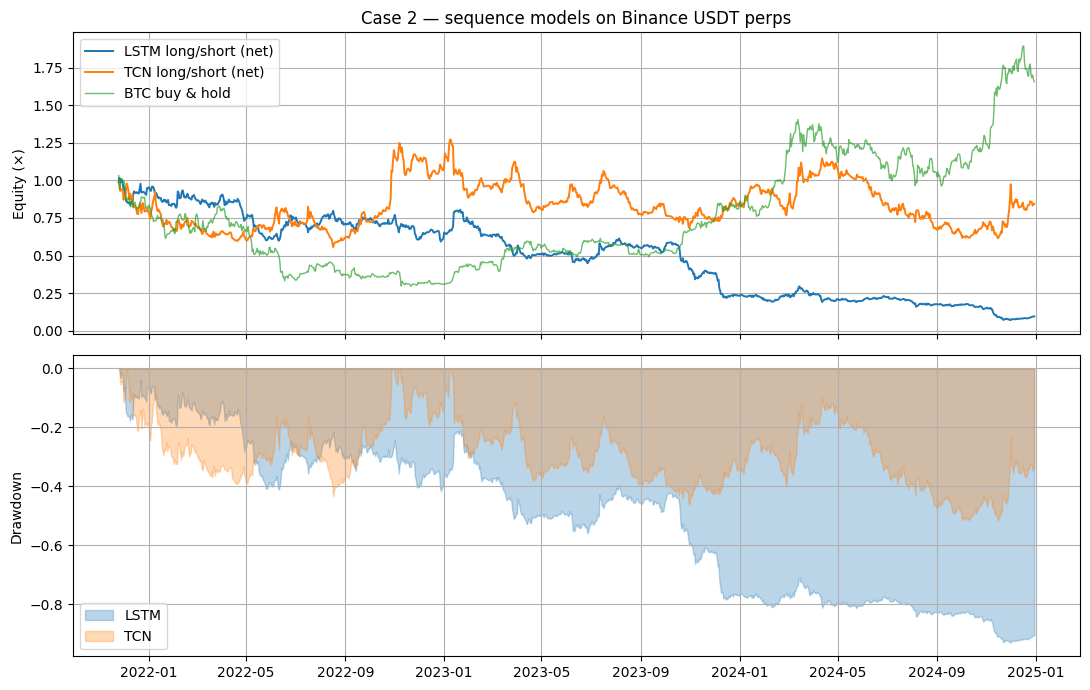

In [8]:
btc_close = px.get('BTCUSDT')
if btc_close is not None:
    bench_ret = btc_close.pct_change().reindex(net_lstm.index).fillna(0.0)
    bench_label = 'BTC buy & hold'
else:
    bench_ret = px.mean(axis=1).pct_change().reindex(net_lstm.index).fillna(0.0)
    bench_label = 'Universe equal-weight'

eq_lstm = (1 + net_lstm).cumprod()
eq_tcn  = (1 + net_tcn).cumprod()
eq_b    = (1 + bench_ret).cumprod()

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(eq_lstm, label='LSTM long/short (net)', linewidth=1.4)
ax[0].plot(eq_tcn,  label='TCN long/short (net)',  linewidth=1.4)
ax[0].plot(eq_b, label=bench_label, linewidth=1.0, alpha=0.7)
ax[0].set_ylabel('Equity (×)')
ax[0].legend()
ax[0].set_title('Case 2 — sequence models on Binance USDT perps')

for series, color, label in (
    (eq_lstm, 'tab:blue', 'LSTM'),
    (eq_tcn, 'tab:orange', 'TCN'),
):
    dd = series / series.cummax() - 1
    ax[1].fill_between(dd.index, dd.values, 0, alpha=0.3, label=label, color=color)
ax[1].set_ylabel('Drawdown')
ax[1].legend()
plt.tight_layout()
plt.show()

## 8. Per-regime breakdown

In [9]:
regimes = trend_regimes(btc_close, window=200).reindex(net_lstm.index) if btc_close is not None else None
if regimes is not None:
    rows = {
        'LSTM': per_regime_metrics(
            net_lstm, regimes,
            metric=lambda x: annualised_sharpe(x, periods_per_year=365),
        ),
        'TCN': per_regime_metrics(
            net_tcn, regimes,
            metric=lambda x: annualised_sharpe(x, periods_per_year=365),
        ),
    }
    pd.DataFrame(rows)
else:
    print('No BTC data → skipping regime split')

## Discussion (fill in with the numbers from your run)

- Did **either** model clear the deflated-Sharpe threshold (≥ 0.95)?
- Were the bootstrap CIs strictly above zero?
- Did the fancier model (TCN) outperform the more popular one (LSTM)? By how much?
- How did both fare in the 2022 bear vs. the 2023–24 rally?
- Did the funding-rate features add anything, or are returns the only useful signal?